In [111]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import sympy as sp

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()

twopi = 2.*np.pi


In [112]:

from scipy.interpolate import interp1d
def interpolate(x, y, x_interp):
    f_int = interp1d(np.log10(x), y, kind='linear', fill_value='extrapolate')
    fek_new = f_int(np.log10(x_interp))
    return fek_new


In [113]:

def SmoothySpec(a,start=None,end=None,width=3):
   b=a.copy()
   if start is None: start = 0
   if end is None: end = len(a)
   for i in range(start,end):
      #b[i+1::][:-1] = 0.25*b[i::][:-2]+0.5*b[i+1::][:-1]+0.25*b[i::][2:]
      b[i+1:-1] = 0.25*b[i:-2] + 0.5*b[i+1:-1] + 0.25*b[i+2:]
   return b


In [114]:

def calc_sf(sf, grid_dims, phys_dims, num_bins=16, log_space=True):
    N = grid_dims[0]
    L = phys_dims[0]
    dx = L/N
    lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx
    if len(grid_dims) == 1:
        lvm_f = lvm_f[N//2:]
    elif len(grid_dims) == 2:
        lvm_f = lvm_f[N//2:,N//2:]
    else:
        lvm_f = lvm_f[N//2:,N//2:,N//2:]
    l_f2, sf2_f2, w_f2 = statistics_base.bin_data(lvm_f, sf, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx, max_bin=L/2., num_bins=N//2, bin_loc='center', log_space=True)
    l_f2_t = l_f2[np.isfinite(sf2_f2)]
    sf2_f2_t = sf2_f2[np.isfinite(sf2_f2)]
    sf2_f2 = strfn_spectra.interpolate(l_f2_t, sf2_f2_t, l_f2)
    #sf2_f2_s = np.exp(SmoothySpec(np.log(sf2_f2)))
    l_b, sf2_b, _ = statistics_base.bin_data(
        l_f2, sf2_f2, bin_func=np.nanmean,
        bin_loc='true_center', log_space=log_space, min_bin=dx, max_bin=L/2.,
        num_bins=num_bins)
    #sf2_b = strfn_spectra.interpolate(l_b, sf2_b, l_f2)
    return (l_f2, sf2_f2), (l_b, sf2_b)


In [115]:

def omni_spectrum(ko, ell, sf2, phys_dims, grid_dims, a, b):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    kk = kk[::-1]
    fek = fek[::-1]

    kmin = np.nanmin(ko)
    kmax = np.nanmax(kk)
    fek = fek[kk > kmin]
    kk = kk[kk > kmin]

    fek = strfn_spectra.interpolate(kk, fek, ko[ko < kmax])
    return ko[ko < kmax], fek


In [116]:

def get_powerlaw(k, fek, num_bins=16, log_space=False):
    est_alpha = np.gradient(np.log(fek), np.log(k))
    b_k, b_est_alpha, _ = statistics_base.bin_data(
        k, est_alpha, bin_func=np.nanmean, log_space=log_space,
        bin_loc='left', num_bins=num_bins, min_bin=np.nanmin(k), max_bin=np.nanmax(k),
        ignore_nan=True)
    est_alpha = interpolate(b_k, b_est_alpha, k)
    return est_alpha

def debias(est_alpha, b, D):
    sp_beta = sp.symbols('beta', positive=True, real=True)
    sp_D = sp.symbols('D', positive=True, real=True)
    sp_b = sp.symbols('b', positive=True, real=True)
    spec_bias = sp.S(2)*sp.S(2)**(-sp_beta) * sp_b**(sp_beta - sp.S(1)) * (sp.gamma(sp_D/sp.S(2)) * sp.gamma((sp.S(3) - sp_beta) / sp.S(2))/sp.gamma(sp_D/sp.S(2) + sp_beta/sp.S(2) - sp.Rational(1,2)))
    spec_bias = spec_bias.subs({sp_D: sp.S(D), sp_b: sp.S(b)})

    bias_factor = []
    est_alpha[est_alpha > -1.01] = -1.01
    est_alpha[est_alpha < -2.99] = -2.99
    for _a in est_alpha:
        bias_factor.append(np.float64(spec_bias.subs({sp_beta: -_a}).evalf()))
    bias_factor = np.array(bias_factor)

    return bias_factor


In [117]:

def plot_sf(raw, binned, title=None):
    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
    ax.plot(raw[0], raw[1], linestyle='-', color='red', linewidth=0.75, label='Raw')
    ax.plot(binned[0], binned[1], linestyle='--', color='blue', linewidth=0.75, label='Binned')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_xlabel(r'Length-scale, $\ell$ [arb. length]')
    ax.set_ylabel(r'SF, $S_2(\ell)$ [arb.]')
    ax.legend(fancybox=False)
    ax.set_title(title)


In [118]:

def plot_powerlaw(feko, fekb1, fekbb, fekb3, title=None):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

    ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
    ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

    ax.plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')
    ax.plot(fekb1[0], fekb1[1], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekbb[0], fekbb[1], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$', marker='o', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekb3[0], fekb3[1], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$', marker='v', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)

    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_xlabel(r'Wavenumber, $k$ [inv. length]')
    ax.set_ylabel(r'd$\ln({\mathcal{E}}(k))/$d$\ln(k)$')
    ax.set_ylim((-5, 1))
    ax.legend(fancybox=True)
    ax.set_title(title)


In [119]:

def plot_spectra(feko, fekb1, fekb2, fekb3, title=None):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

    ax.plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')

    #ax.plot(fekb1[0], fekb1[1], color='red', linestyle=':', linewidth=0.5)
    #ax.plot(fekb2[0], fekb2[1], color='green', linestyle=':', linewidth=0.5)
    #ax.plot(fekb3[0], fekb3[1], color='blue', linestyle=':', linewidth=0.5)

    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_xlabel(r'Wavenumber, $k$ [inv. length]')
    ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [arb.]')

    max_v = np.nanmax([np.nanmax(feko[1]), np.nanmax(fekb1[1]), np.nanmax(fekb2[1]), np.nanmax(fekb3[1])])
    min_v = feko[1][-1]
    ax.set_ylim((min_v, max_v))

    ax.legend(fancybox=True)
    ax.set_title(title)


In [120]:

def plot_spectra_bias(feko, fekb1, fekb2, fekb3, title=None):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

    kmax = np.nanmax(feko[0])
    k_same = feko[0][feko[0] <= kmax]
    fek_same = feko[1][feko[1] <= kmax]

    feks1 = strfn_spectra.interpolate(k_same, fek_same, fekb1[0])
    feks2 = strfn_spectra.interpolate(k_same, fek_same, fekb2[0])
    feks3 = strfn_spectra.interpolate(k_same, fek_same, fekb3[0])

    #ax.plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')
    ax.plot(fekb1[0], fekb1[1]/fekb1[2]/feks1, color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax.plot(fekb2[0], fekb2[1]/fekb2[2]/feks2, color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax.plot(fekb3[0], fekb3[1]/fekb3[2]/feks3, color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_xlabel(r'Wavenumber, $k$ [inv. length]')
    ax.set_ylabel(r'Bias')

    ax.set_ylim((1e-1, 1e1))

    ax.legend(fancybox=False)
    ax.set_title(title)


In [121]:

def plot_spectra_and_bias(feko, fekb1, fekb2, fekb3, title=None):

    fig = plt.figure(dpi=256, figsize=(3.5, 2.625))
    gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[1, 0.5], figure=fig, hspace=0., wspace=0.05)
    ax = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

    ax[0].plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')

    ax[0].plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax[0].plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax[0].plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].yaxis.set_ticks_position('both')
    ax[0].xaxis.set_ticks_position('both')
    ax[0].tick_params(axis='y', direction='in')
    ax[0].tick_params(axis='y', direction='in', which='minor')
    ax[0].tick_params(axis='x', direction='in')
    ax[0].tick_params(axis='x', direction='in', which='minor')
    ax[0].grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    #ax.set_xlabel(r'Wavenumber, $k$ [inv. length]')
    ax[0].set_ylabel(r'PSD, $\mathcal{E}(k)$ [arb.]')
    ax[0].set_xticklabels([])

    max_v = np.nanmax([np.nanmax(feko[1]), np.nanmax(fekb1[1]), np.nanmax(fekb2[1]), np.nanmax(fekb3[1])])
    #min_v = feko[1][-1]
    min_v = np.nanmin([np.nanmin(fekb1[1]), np.nanmin(fekb2[1]), np.nanmin(fekb3[1])])
    ax[0].set_ylim((min_v-0.1*min_v, max_v+0.1*max_v))

    #max_v = np.nanmax([np.nanmax(fekb1[0]), np.nanmax(fekb2[0]), np.nanmax(fekb3[0])])
    #min_v = np.nanmin([np.nanmin(fekb1[0]), np.nanmin(fekb2[0]), np.nanmin(fekb3[0])])
    min_v, max_v = np.nanmin(feko[0]), np.nanmax(feko[0])
    ax[0].set_xlim((min_v-0.1*min_v, max_v+0.1*max_v))

    ax[0].legend(fancybox=False)
    ax[0].set_title(title)

    kmax = np.nanmax(feko[0])
    k_same = feko[0][feko[0] <= kmax]
    fek_same = feko[1][feko[1] <= kmax]

    feks1 = strfn_spectra.interpolate(k_same, fek_same, fekb1[0])
    feks2 = strfn_spectra.interpolate(k_same, fek_same, fekb2[0])
    feks3 = strfn_spectra.interpolate(k_same, fek_same, fekb3[0])

    #ax.plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')
    mape1 = np.nanmean((feks1 - fekb1[1]/fekb1[2]) / feks1)
    mape2 = np.nanmean((feks2 - fekb2[1]/fekb2[2]) / feks2)
    mape3 = np.nanmean((feks3 - fekb3[1]/fekb3[2]) / feks3)
    ax[1].plot(fekb1[0], fekb1[1]/fekb1[2]/feks1, color='red', linestyle='--', linewidth=0.5, label=r'%s' % mape1.round(decimals=2))
    ax[1].plot(fekb2[0], fekb2[1]/fekb2[2]/feks2, color='green', linestyle='--', linewidth=0.5, label=r'%s' % mape2.round(decimals=2))
    ax[1].plot(fekb3[0], fekb3[1]/fekb3[2]/feks3, color='blue', linestyle='--', linewidth=0.5, label=r'%s' % mape3.round(decimals=2))

    ax[1].set_xscale('log')
    ax[1].set_yscale('log')
    ax[1].yaxis.set_ticks_position('both')
    ax[1].xaxis.set_ticks_position('both')
    ax[1].tick_params(axis='y', direction='in')
    ax[1].tick_params(axis='y', direction='in', which='minor')
    ax[1].tick_params(axis='x', direction='in')
    ax[1].tick_params(axis='x', direction='in', which='minor')
    ax[1].grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax[1].set_xlabel(r'Wavenumber, $k$ [inv. length]')
    ax[1].set_ylabel(r'Bias')

    ax[1].set_ylim((0.5, 2))

    ax[1].set_xlim(ax[0].get_xlim())

    ax[1].legend(fancybox=False)

    fig.align_ylabels()

    #ax.set_title(title)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


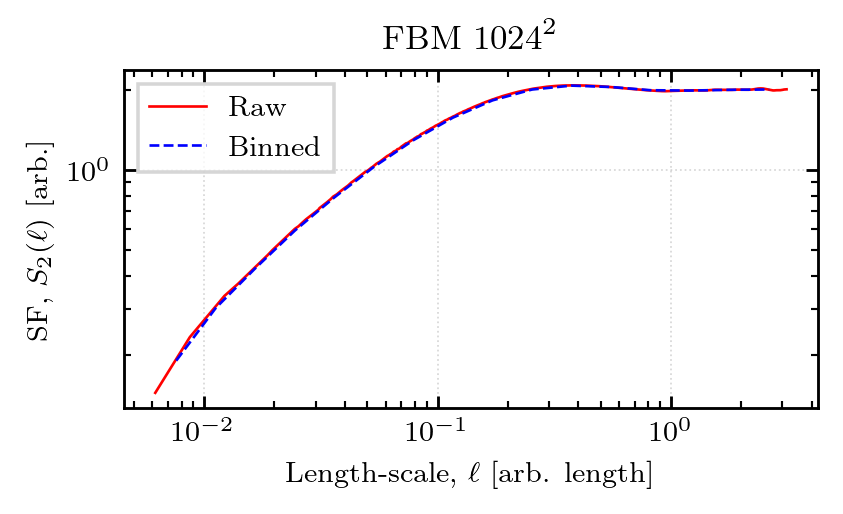

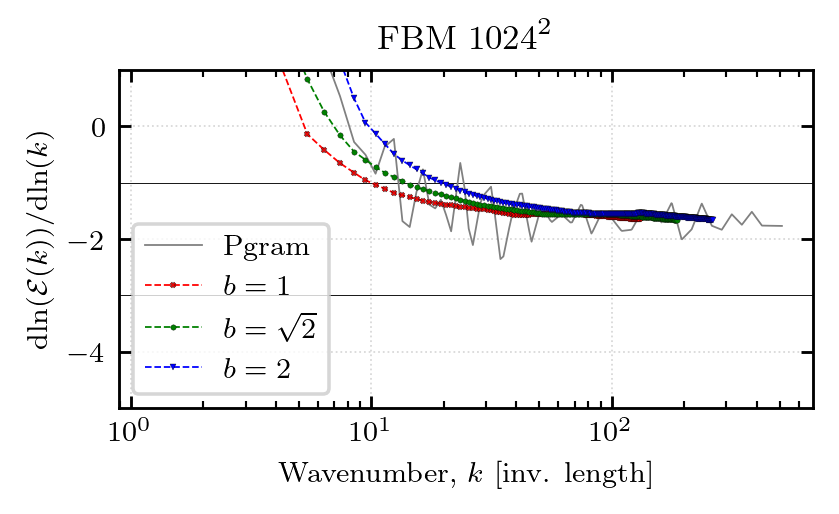

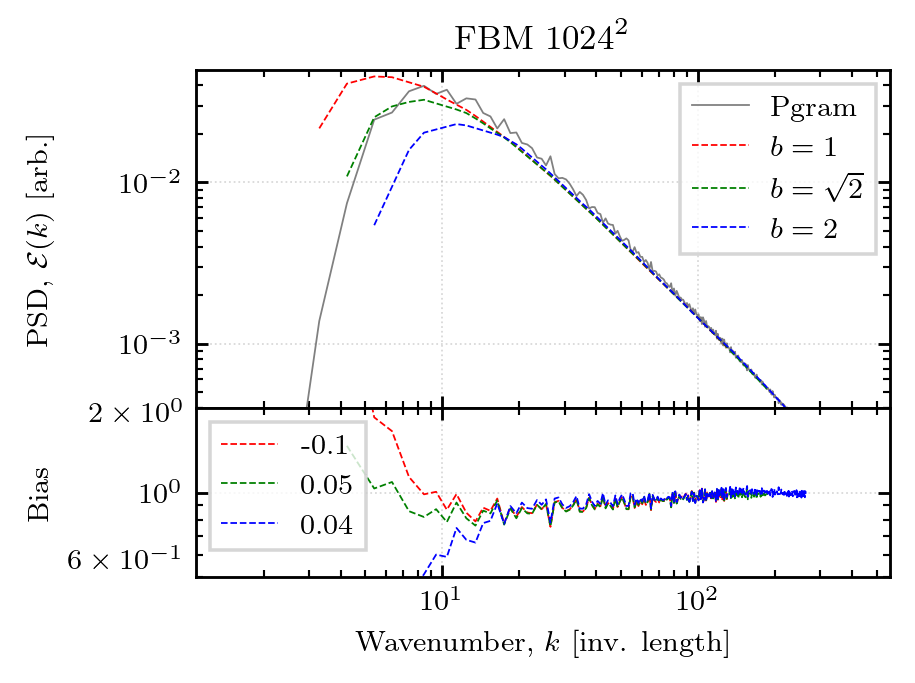

In [122]:

## FBM 1024^2
file0 = h5.File('SF_TEST/2_1024/in/T.Fr.h5', 'r')
field0 = np.array(file0['T.Fr'])
file2 = h5.File('SF_TEST/2_1024/out/SF_Grid_scalar.h5', 'r')
sf_f2 = np.array(file2['SF_Grid_scalar2'])

grid_dims = (1024, 1024)
phys_dims = (twopi, twopi)
dk = twopi/phys_dims[0]
_title = 'FBM $1024^2$'


## Make strfn
sf_r, sf_b = calc_sf(sf_f2, grid_dims, phys_dims, 16)
l_r, sf_r = sf_r
l_b, sf_b = sf_b
## Plot strfn
plot_sf((l_r, sf_r), (l_b, sf_b), title=_title)

## Make spectrum
kD, fekD = per_spectra.modal_spectrum(field0, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**len(grid_dims)
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
## Get equiv-spectrum
kb1, fekb1 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 1., 1.)
kb2, fekb2 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
kb3, fekb3 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 2., 2.)

## Estimate powerlaw
a_feko = get_powerlaw(ko, feko, num_bins=len(ko)//8, log_space=True)
a_fekb1 = get_powerlaw(kb1, fekb1, log_space=True, num_bins=16)
a_fekb2 = get_powerlaw(kb2, fekb2, log_space=True, num_bins=16)
a_fekb3 = get_powerlaw(kb3, fekb3, log_space=True, num_bins=16)
## Plot powerlaw
plot_powerlaw((ko, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=_title)

## Get debiasing factors
b_b1 = debias(a_fekb1, 1., len(grid_dims))
b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
b_b3 = debias(a_fekb3, 2., len(grid_dims))
## Plot spectra
#plot_spectra((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot bias to periodogram
#plot_spectra_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot spectra and bias
plot_spectra_and_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


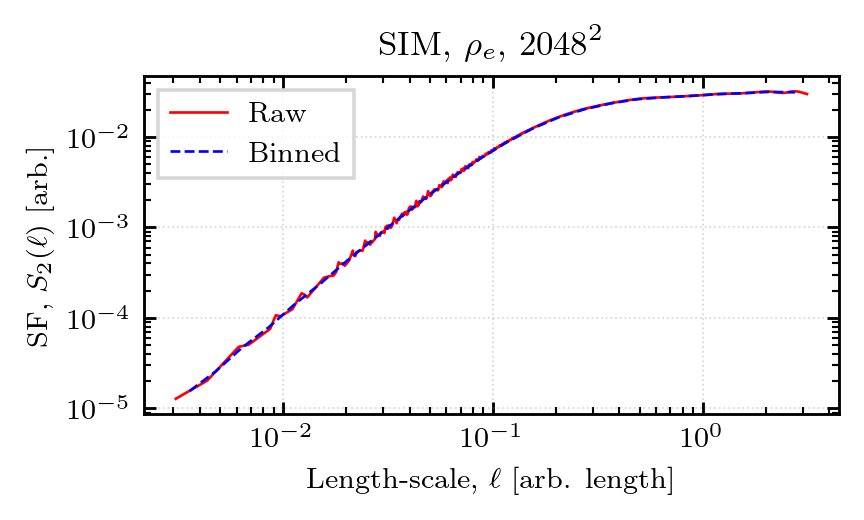

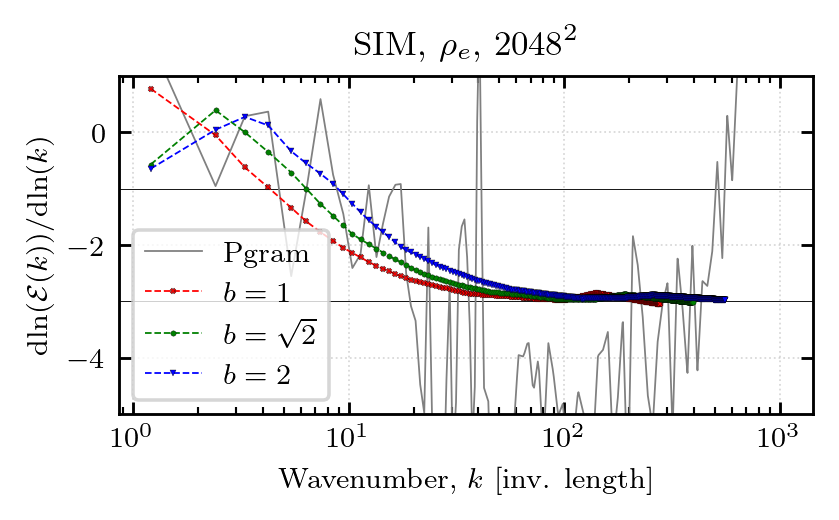

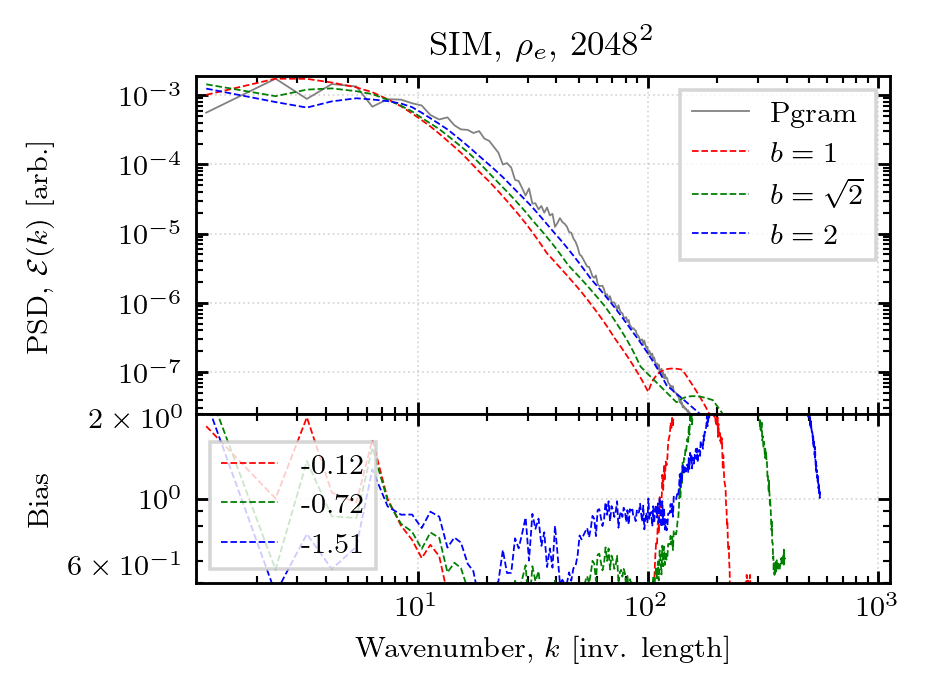

In [123]:

## SIM 2048^2
file0 = h5.File('SIMS_SF/2_2048_rho_e/in/T.Fr.h5', 'r')
field0 = np.array(file0['T.Fr'])
file2 = h5.File('SIMS_SF/2_2048_rho_e/out/SF_Grid_scalar.h5', 'r')
sf_f2 = np.array(file2['SF_Grid_scalar2'])

grid_dims = (2048, 2048)
phys_dims = (twopi, twopi)
dk = twopi/phys_dims[0]
_title = r'SIM, $\rho_e$, $2048^2$'

## Make strfn
sf_r, sf_b = calc_sf(sf_f2, grid_dims, phys_dims, 24)
l_r, sf_r = sf_r
l_b, sf_b = sf_b
## Plot strfn
plot_sf((l_r, sf_r), (l_b, sf_b), title=_title)

## Make spectrum
kD, fekD = per_spectra.modal_spectrum(field0, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**len(grid_dims)
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
## Get equiv-spectrum
kb1, fekb1 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 1., 1.)
kb2, fekb2 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
kb3, fekb3 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 2., 2.)

## Estimate powerlaw
a_feko = get_powerlaw(ko, feko, num_bins=len(ko)//8, log_space=True)
a_fekb1 = get_powerlaw(kb1, fekb1, log_space=True, num_bins=16)
a_fekb2 = get_powerlaw(kb2, fekb2, log_space=True, num_bins=16)
a_fekb3 = get_powerlaw(kb3, fekb3, log_space=True, num_bins=16)
## Plot powerlaw
plot_powerlaw((ko, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=_title)

## Get debiasing factors
b_b1 = debias(a_fekb1, 1., len(grid_dims))
b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
b_b3 = debias(a_fekb3, 2., len(grid_dims))
## Plot spectra
#plot_spectra((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot bias to periodogram
#plot_spectra_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot spectra and bias
plot_spectra_and_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


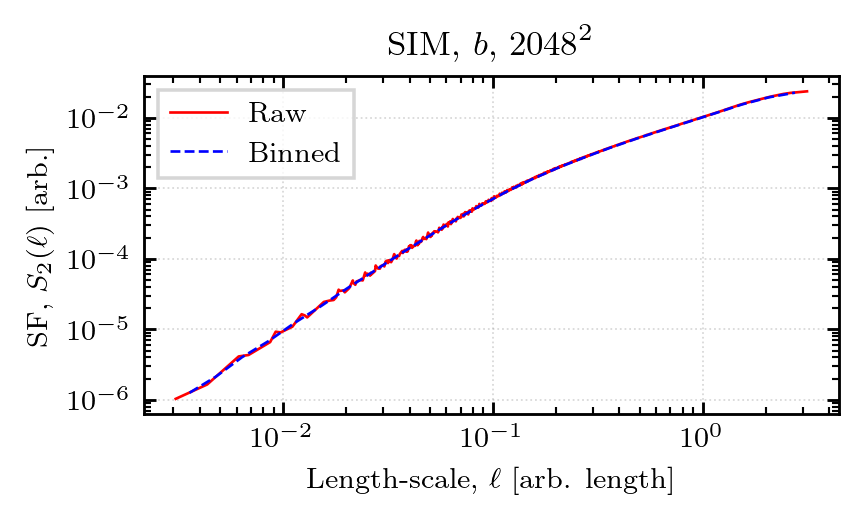

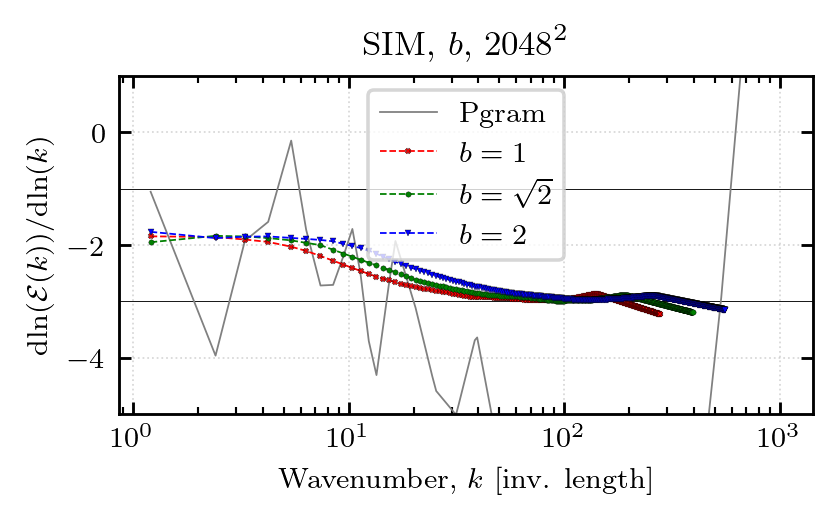

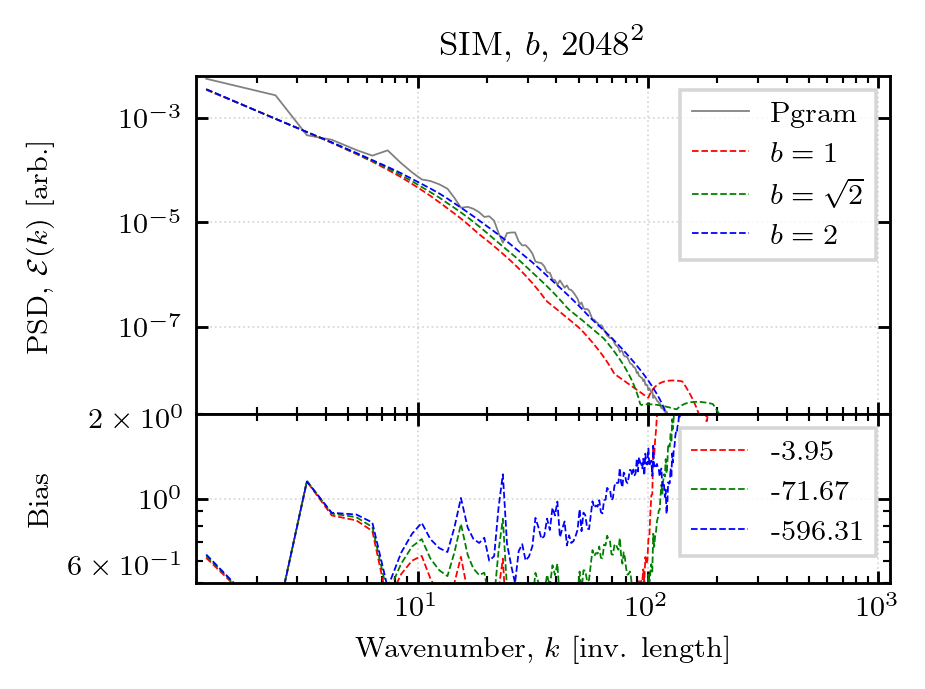

In [128]:

## SIM 2048^2
file0_x = h5.File('SIMS_SF/2_2048_b/in/U.V1r.h5', 'r')
field0_x = np.array(file0_x['U.V1r'])
file0_y = h5.File('SIMS_SF/2_2048_b/in/U.V2r.h5', 'r')
field0_y = np.array(file0_y['U.V2r'])
file0_z = h5.File('SIMS_SF/2_2048_b/in/U.V3r.h5', 'r')
field0_z = np.array(file0_z['U.V3r'])
field0_z = field0_z - np.mean(field0_z)

file2_x = h5.File('SIMS_SF/2_2048_b/out/SF_Grid_scalar_x.h5', 'r')
sf_f2_x = np.array(file2_x['SF_Grid_scalar2'])
file2_y = h5.File('SIMS_SF/2_2048_b/out/SF_Grid_scalar_y.h5', 'r')
sf_f2_y = np.array(file2_y['SF_Grid_scalar2'])
file2_z = h5.File('SIMS_SF/2_2048_b/out/SF_Grid_scalar_z.h5', 'r')
sf_f2_z = np.array(file2_z['SF_Grid_scalar2'])

sf_f2 = sf_f2_x + sf_f2_y + sf_f2_z

grid_dims = (2048, 2048)
phys_dims = (twopi, twopi)
dk = twopi/phys_dims[0]
_title = 'SIM, $b$, $2048^2$'

## Make strfn
sf_r, sf_b = calc_sf(sf_f2, grid_dims, phys_dims, 24)
l_r, sf_r = sf_r
l_b, sf_b = sf_b
## Plot strfn
plot_sf((l_r, sf_r), (l_b, sf_b), title=_title)

## Make spectrum
kDx, fekDx = per_spectra.modal_spectrum(field0_x, phys_dims=phys_dims)
kDy, fekDy = per_spectra.modal_spectrum(field0_y, phys_dims=phys_dims)
kDz, fekDz = per_spectra.modal_spectrum(field0_z, phys_dims=phys_dims)
kD = kDx
fekD = fekDx + fekDy + fekDz
fekD = fekD * (dk/twopi)**len(grid_dims)
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
## Get equiv-spectrum
kb1, fekb1 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 1., 1.)
kb2, fekb2 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
kb3, fekb3 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 2., 2.)

## Estimate powerlaw
a_feko = get_powerlaw(ko, feko, num_bins=len(ko)//32, log_space=True)
a_fekb1 = get_powerlaw(kb1, fekb1, log_space=True, num_bins=16)
a_fekb2 = get_powerlaw(kb2, fekb2, log_space=True, num_bins=16)
a_fekb3 = get_powerlaw(kb3, fekb3, log_space=True, num_bins=16)
## Plot powerlaw
plot_powerlaw((ko, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=_title)

## Get debiasing factors
b_b1 = debias(a_fekb1, 1., len(grid_dims))
b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
b_b3 = debias(a_fekb3, 2., len(grid_dims))
## Plot spectra
#plot_spectra((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot bias to periodogram
#plot_spectra_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot spectra and bias
plot_spectra_and_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


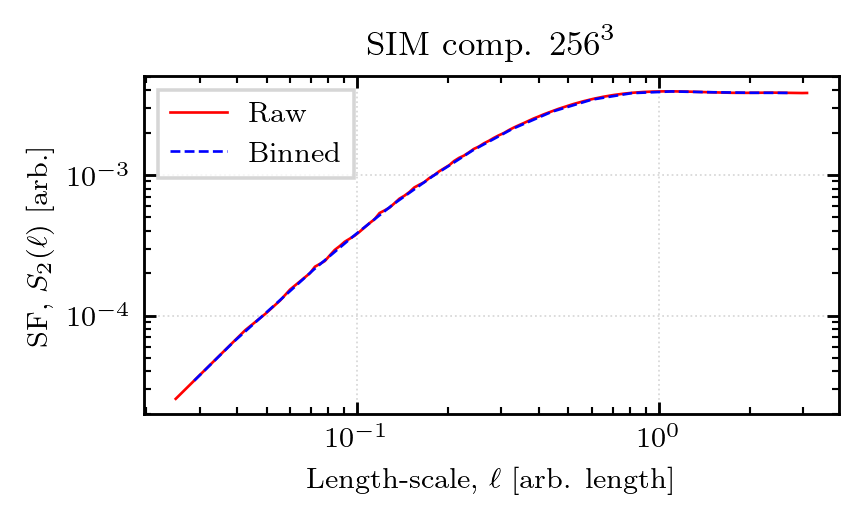

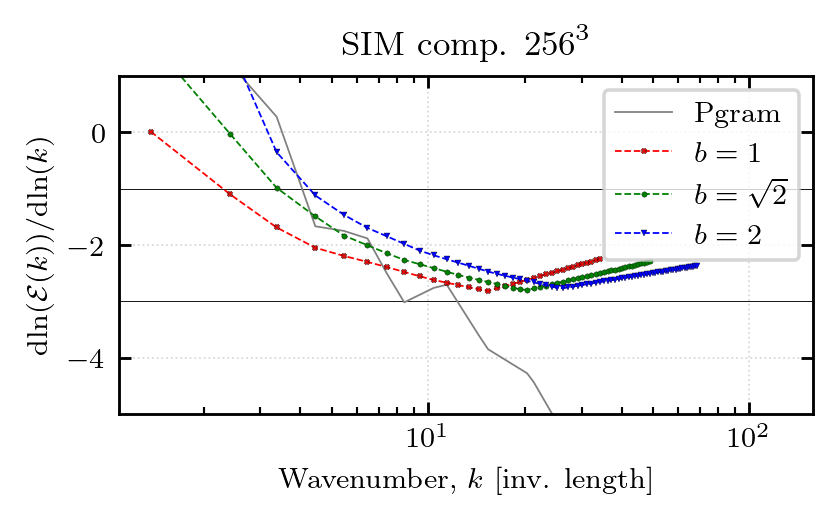

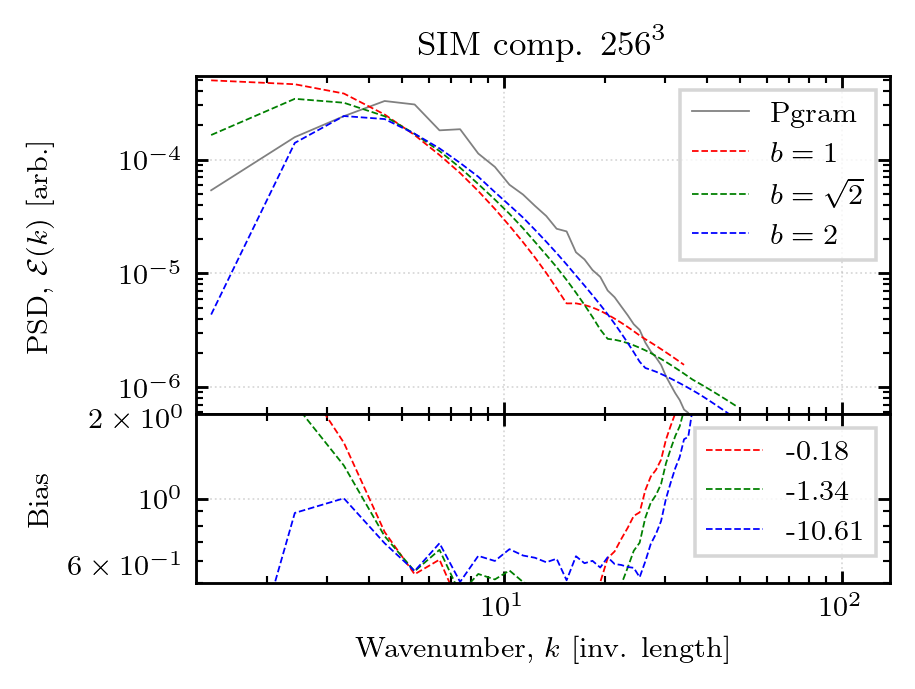

In [125]:

## SIM 256^3
file0 = h5.File('SIMS_SF/3_256/in/T.Fr.h5', 'r')
field0 = np.array(file0['T.Fr'])
file2 = h5.File('SIMS_SF/3_256/out/SF_Grid_scalar.h5', 'r')
sf_f2 = np.array(file2['SF_Grid_scalar2'])

grid_dims = (256, 256, 256)
phys_dims = (twopi, twopi, twopi)
dk = twopi/phys_dims[0]
_title = 'SIM comp. $256^3$'

## Make strfn
sf_r, sf_b = calc_sf(sf_f2, grid_dims, phys_dims, 16)
l_r, sf_r = sf_r
l_b, sf_b = sf_b
## Plot strfn
plot_sf((l_r, sf_r), (l_b, sf_b), title=_title)

## Make spectrum
kD, fekD = per_spectra.modal_spectrum(field0, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**len(grid_dims)
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
## Get equiv-spectrum
kb1, fekb1 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 1., 1.)
kb2, fekb2 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
kb3, fekb3 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 2., 2.)

## Estimate powerlaw
a_feko = get_powerlaw(ko, feko, num_bins=len(ko)//8, log_space=True)
a_fekb1 = get_powerlaw(kb1, fekb1, log_space=True, num_bins=8)
a_fekb2 = get_powerlaw(kb2, fekb2, log_space=True, num_bins=8)
a_fekb3 = get_powerlaw(kb3, fekb3, log_space=True, num_bins=8)
## Plot powerlaw
plot_powerlaw((ko, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=_title)

## Get debiasing factors
b_b1 = debias(a_fekb1, 1., len(grid_dims))
b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
b_b3 = debias(a_fekb3, 2., len(grid_dims))
## Plot spectra
#plot_spectra((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot bias to periodogram
#plot_spectra_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot spectra and bias
plot_spectra_and_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


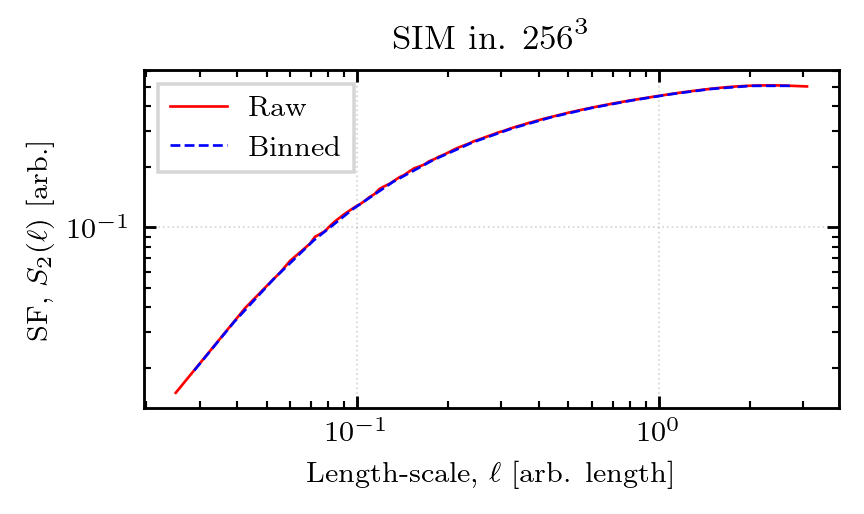

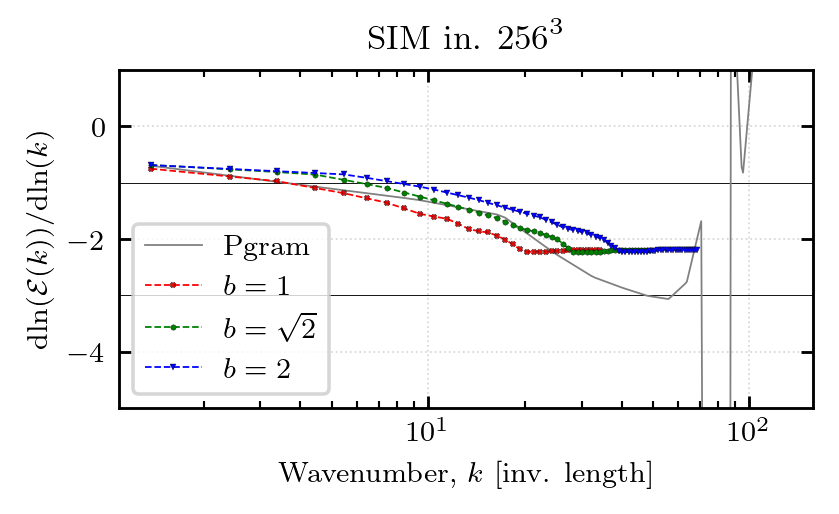

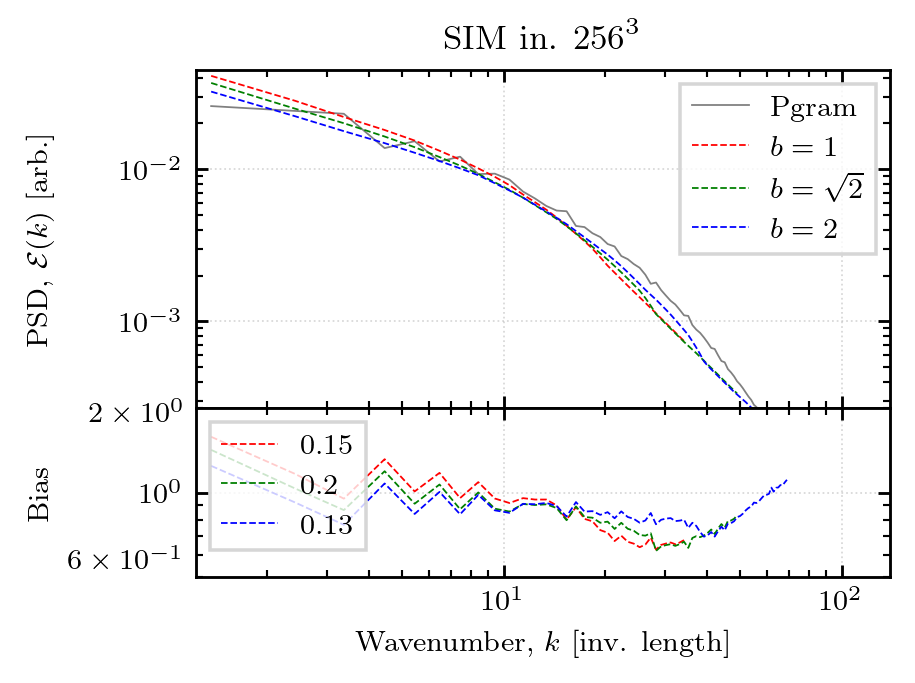

In [126]:

## SIM incompressible 256^3
file0_x = h5.File('SIMS_SF/3_256_in_v/in/U.V1r.h5', 'r')
field0_x = np.array(file0_x['U.V1r'])
file0_y = h5.File('SIMS_SF/3_256_in_v/in/U.V2r.h5', 'r')
field0_y = np.array(file0_y['U.V2r'])
file0_z = h5.File('SIMS_SF/3_256_in_v/in/U.V3r.h5', 'r')
field0_z = np.array(file0_z['U.V3r'])

file2_perp = h5.File('SIMS_SF/3_256_in_v/out/SF_Grid_perp.h5', 'r')
sf_f2_perp = np.array(file2_perp['SF_Grid_perp2'])
file2_pll = h5.File('SIMS_SF/3_256_in_v/out/SF_Grid_pll.h5', 'r')
sf_f2_pll = np.array(file2_pll['SF_Grid_pll2'])
sf_f2 = sf_f2_perp + sf_f2_pll

grid_dims = (256, 256, 256)
phys_dims = (twopi, twopi, twopi)
dk = twopi/phys_dims[0]
_title = 'SIM in. $256^3$'

## Make strfn
sf_r, sf_b = calc_sf(sf_f2, grid_dims, phys_dims, 16)
l_r, sf_r = sf_r
l_b, sf_b = sf_b
## Plot strfn
plot_sf((l_r, sf_r), (l_b, sf_b), title=_title)

## Make spectrum
kDx, fekDx = per_spectra.modal_spectrum(field0_x, phys_dims=phys_dims)
kDy, fekDy = per_spectra.modal_spectrum(field0_y, phys_dims=phys_dims)
kDz, fekDz = per_spectra.modal_spectrum(field0_z, phys_dims=phys_dims)
kD = kDx
fekD = fekDx + fekDy + fekDz
fekD = fekD * (dk/twopi)**len(grid_dims)
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
## Get equiv-spectrum
kb1, fekb1 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 1., 1.)
kb2, fekb2 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
kb3, fekb3 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 2., 2.)

## Estimate powerlaw
a_feko = get_powerlaw(ko, feko)
a_fekb1 = get_powerlaw(kb1, fekb1)
a_fekb2 = get_powerlaw(kb2, fekb2)
a_fekb3 = get_powerlaw(kb3, fekb3)
## Plot powerlaw
plot_powerlaw((ko, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=_title)

## Get debiasing factors
b_b1 = debias(a_fekb1, 1., len(grid_dims))
b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
b_b3 = debias(a_fekb3, 2., len(grid_dims))
## Plot spectra
#plot_spectra((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot bias to periodogram
#plot_spectra_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
## Plot spectra and bias
plot_spectra_and_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)


In [127]:

# ## FBM 512^3
# file0 = h5.File('SF_TEST/3_512/in/T.Fr.h5', 'r')
# field0 = np.array(file0['T.Fr'])
# file2 = h5.File('SF_TEST/3_512/out/SF_Grid_scalar.h5', 'r')
# sf_f2 = np.array(file2['SF_Grid_scalar2'])

# grid_dims = (512, 512, 512)
# phys_dims = (twopi, twopi, twopi)
# dk = twopi/phys_dims[0]
# _title = 'FBM $512^3$'

# ## Make strfn
# sf_r, sf_b = calc_sf(sf_f2, grid_dims, phys_dims, 15)
# l_r, sf_r = sf_r
# l_b, sf_b = sf_b
# ## Plot strfn
# plot_sf((l_r, sf_r), (l_b, sf_b), title=_title)

# ## Make spectrum
# fekD = np.load('3_512_fekD.npy')
# kD = np.load('3_512_kD.npy')
# ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
# ## Get equiv-spectrum
# kb1, fekb1 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 1., 1.)
# kb2, fekb2 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
# kb3, fekb3 = omni_spectrum(ko, l_b, sf_b, phys_dims, grid_dims, 2., 2.)

# ## Estimate powerlaw
# a_feko = get_powerlaw(ko, np.exp(SmoothySpec(np.log(feko))))
# a_fekb1 = get_powerlaw(kb1, fekb1)
# a_fekb2 = get_powerlaw(kb2, fekb2)
# a_fekb3 = get_powerlaw(kb3, fekb3)
# ## Plot powerlaw
# plot_powerlaw((ko, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=_title)


# ## Get debiasing factors
# b_b1 = debias(a_fekb1, 1., len(grid_dims))
# b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
# b_b3 = debias(a_fekb3, 2., len(grid_dims))
# ## Plot spectra
# #plot_spectra((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
# ## Plot bias to periodogram
# #plot_spectra_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
# ## Plot spectra and bias
# plot_spectra_and_bias((ko, feko), (kb1, fekb1, b_b1), (kb2, fekb2, b_b2), (kb3, fekb3, b_b3), title=_title)
